In [1]:
import sys
from pathlib import Path
prediction_mode_path = Path("../module")
sys.path.append(prediction_mode_path.as_posix())
import models_creation as pred_model

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#from sklearn import tree

from matplotlib import pyplot as plt

import joblib

from mordred import Calculator, descriptors
import mordred
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

import warnings
warnings.filterwarnings('ignore')

In [2]:
molecular_descriptors_df = pred_model.prepare_data('../Data/QSPR_epoxidation_model_III.xlsx')

 29%|███████████████████████▊                                                          | 18/62 [00:01<00:03, 13.50it/s]

C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaco

100%|██████████████████████████████████████████████████████████████████████████████████| 62/62 [00:01<00:00, 37.94it/s]


C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
Data size (rows, columns): (62, 3874)
Data size after first reduction (rows, columns): (62, 3227)
Data size after second reduction (rows, columns): (62, 1340)


In [3]:
model = joblib.load("models/random_forest_model_8_estimators_EE.joblib")

In [4]:
predicted_activity = model.predict(molecular_descriptors_df[list(model.feature_names_in_)])

In [5]:
predicted_activity

array([84.375  , 51.75   , 93.5    , 56.75   , 55.5    , 92.     ,
       95.3125 , 96.75   , 90.375  , 90.9375 , 72.75   , 81.375  ,
       69.75   , 94.375  , 94.375  , 59.     , 94.125  , 90.375  ,
       90.9375 , 75.75   , 89.25   , 81.125  , 83.0625 , 61.75   ,
       71.     , 30.375  , 26.25   , 66.46875, 78.     , 75.75   ,
       88.25   , 86.25   , 80.5    , 64.5    , 53.5    , 79.03125,
       51.75   , 29.25   , 30.375  , 66.46875, 30.375  , 68.75   ,
       39.375  , 75.     , 21.5    , 11.     , 88.125  , 23.     ,
       66.5    , 31.25   , 66.5    , 78.375  , 55.125  , 12.     ,
       10.875  , 70.375  , 12.     , 64.     , 67.5    , 30.375  ,
        3.75   , 35.     ])

In [6]:
molecular_descriptors_df.head()

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2017,C_FP_2023,C_FP_2029,C_FP_2033,C_FP_2041,ee
0,26.682927,5.770088,3.024390,6.178260,153.267812,105.649934,1.844467,5.906402,3.601607,7.350701,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,80.0
1,25.935484,5.706245,2.580645,4.751892,158.057747,102.435555,1.691055,5.821371,3.519689,7.342506,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46.0
2,23.860465,5.661247,2.744186,4.914154,157.443307,94.120542,1.670321,5.779477,3.312805,7.283060,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,95.0
3,24.764706,5.671282,2.529412,4.450254,158.718230,97.699954,1.650025,5.783676,3.334128,7.311622,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
4,24.764706,5.671282,2.588235,4.567901,158.718230,97.699954,1.650025,5.783676,3.349651,7.311622,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.0


In [7]:
molecular_descriptors_df[list(model.feature_names_in_)]

,ATSC5v,NdssC
0,335.805685,1
1,235.634091,1
2,186.623841,1
3,569.375837,1
4,78.203068,2
...,...,...
57,26.062117,2
58,558.163585,2
59,-184.211894,2
60,-428.141827,2


In [8]:
model.feature_names_in_

array(['ATSC5v', 'NdssC'], dtype=object)

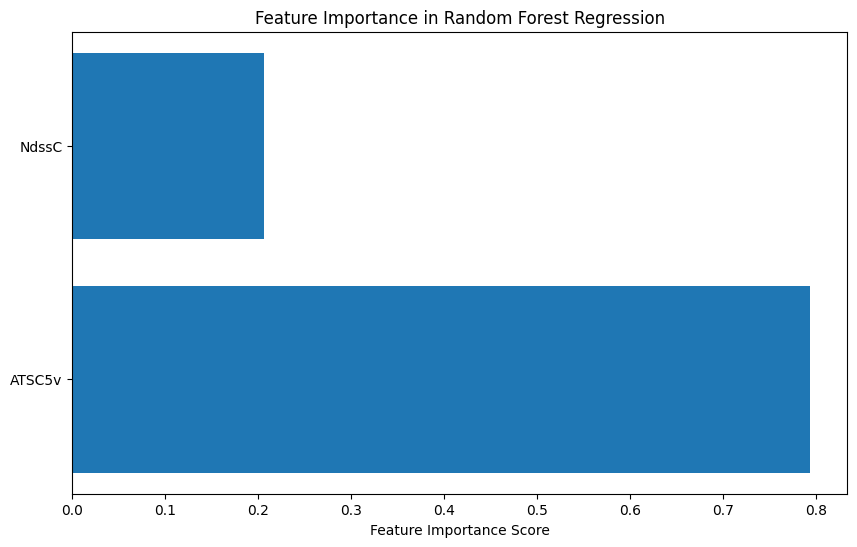

In [9]:
# Get feature importances
importances = model.feature_importances_

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(molecular_descriptors_df[list(model.feature_names_in_)].columns, importances)
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance in Random Forest Regression')
plt.show()


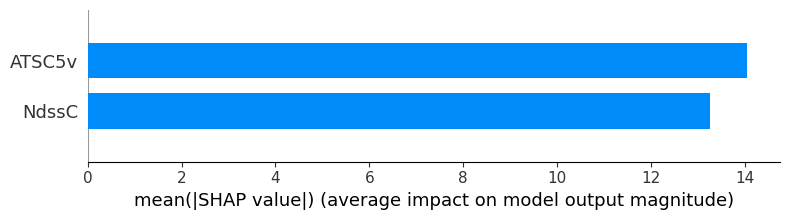

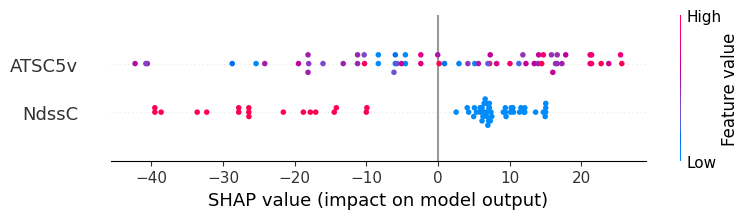

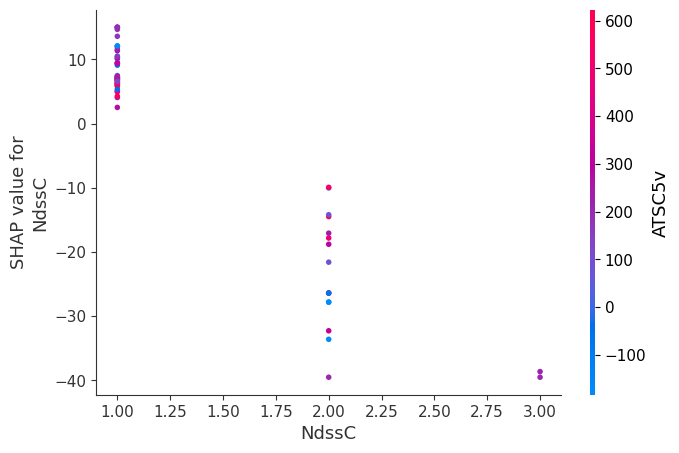

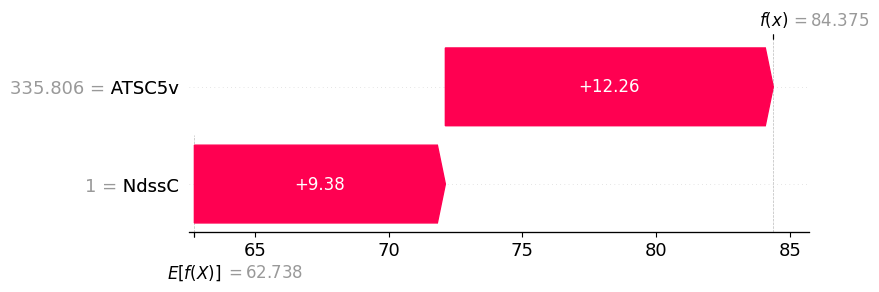

In [10]:
import shap
# 3. Initialize SHAP Explainer
explainer = shap.TreeExplainer(model)

# 4. Calculate SHAP Values
shap_values = explainer.shap_values(molecular_descriptors_df[list(model.feature_names_in_)])  # Calculate on test set

# 5. Visualizations

# 5.1. Force Plot (as in your original code)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], molecular_descriptors_df[list(model.feature_names_in_)].iloc[0])

# 5.2. Summary Plot (Bar Chart)
shap.summary_plot(shap_values, molecular_descriptors_df[list(model.feature_names_in_)], plot_type="bar")

# 5.3. Summary Plot (Violin Plot - also known as Beeswarm plot)
shap.summary_plot(shap_values, molecular_descriptors_df[list(model.feature_names_in_)])  # Default plot_type is "dot" (beeswarm)

# 5.4. Dependence Plot (for a single feature)
shap.dependence_plot("NdssC", shap_values, molecular_descriptors_df[list(model.feature_names_in_)])

# 5.5. Waterfall Plot (for a single instance)
import matplotlib.pyplot as plt # add this import
shap.waterfall_plot(shap.Explanation(values=shap_values[0],
                                          base_values=explainer.expected_value,
                                          data=molecular_descriptors_df[list(model.feature_names_in_)].iloc[0],
                                          feature_names=molecular_descriptors_df[list(model.feature_names_in_)].columns))
plt.show()

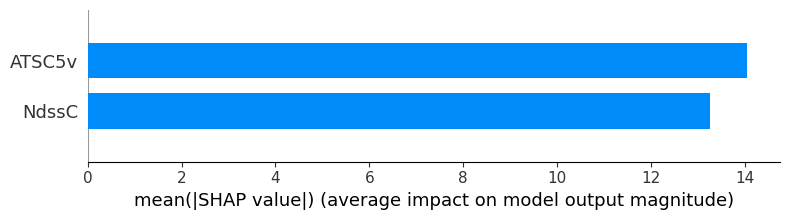

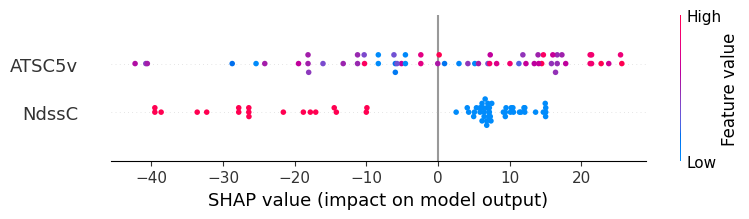

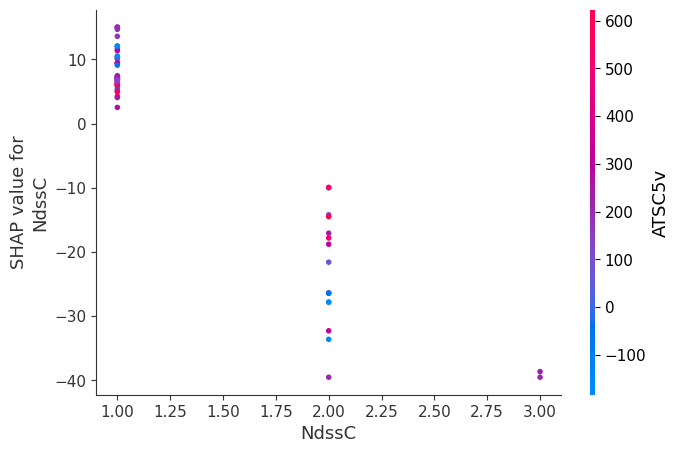

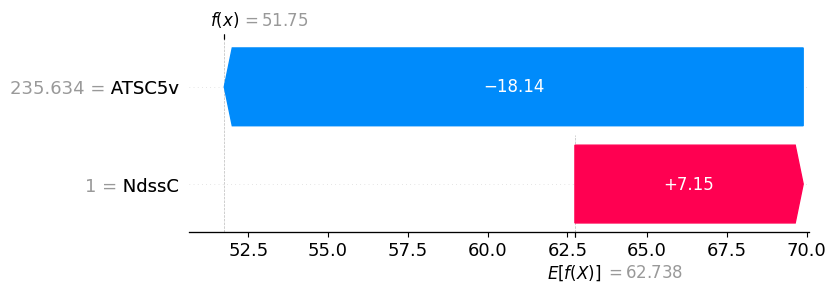

In [11]:
import shap
# 3. Initialize SHAP Explainer
explainer = shap.TreeExplainer(model)

# 4. Calculate SHAP Values
shap_values = explainer.shap_values(molecular_descriptors_df[list(model.feature_names_in_)])  # Calculate on test set

# 5. Visualizations

# 5.1. Force Plot (as in your original code)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[1], molecular_descriptors_df[list(model.feature_names_in_)].iloc[1])

# 5.2. Summary Plot (Bar Chart)
shap.summary_plot(shap_values, molecular_descriptors_df[list(model.feature_names_in_)], plot_type="bar")

# 5.3. Summary Plot (Violin Plot - also known as Beeswarm plot)
shap.summary_plot(shap_values, molecular_descriptors_df[list(model.feature_names_in_)])  # Default plot_type is "dot" (beeswarm)

# 5.4. Dependence Plot (for a single feature)
shap.dependence_plot("NdssC", shap_values, molecular_descriptors_df[list(model.feature_names_in_)])

# 5.5. Waterfall Plot (for a single instance)
import matplotlib.pyplot as plt # add this import
shap.waterfall_plot(shap.Explanation(values=shap_values[1],
                                          base_values=explainer.expected_value,
                                          data=molecular_descriptors_df[list(model.feature_names_in_)].iloc[1],
                                          feature_names=molecular_descriptors_df[list(model.feature_names_in_)].columns))
plt.show()

In [12]:
import pandas as pd # Make sure you have pandas imported
import numpy as np

# Assuming molecular_descriptors_df[features] is your series of descriptor values
# and you have a trained RandomForestRegressor model named 'rf'

# 1.  Extract the descriptor values as a NumPy array (or list):

descriptor_values = molecular_descriptors_df[list(model.feature_names_in_)].iloc[0].values  # This is now a NumPy array

#   Important:  Make absolutely sure that the order of features
#   in `molecular_descriptors_df[features]` *exactly* matches the order
#   the model was trained on!  This is crucial for meaningful results.
#   If `features` is a list of column names, then
#   `molecular_descriptors_df[features]` already guarantees correct order.

# 2.  Reshape the descriptor values:

# Reshape the array so it has the correct dimensions (1 sample, n features)
descriptor_values_reshaped = descriptor_values.reshape(1, -1)

# 3. Get Individual Tree Predictions:

individual_tree_predictions = [tree.predict(descriptor_values_reshaped) for tree in model.estimators_]

# 4. Print the predictions
print("Predictions from individual trees:", individual_tree_predictions)


Predictions from individual trees: [array([85.]), array([80.]), array([80.]), array([80.]), array([95.]), array([80.]), array([80.]), array([95.])]


In [13]:
import pandas as pd # Make sure you have pandas imported
import numpy as np

# Assuming molecular_descriptors_df[features] is your series of descriptor values
# and you have a trained RandomForestRegressor model named 'rf'

# 1.  Extract the descriptor values as a NumPy array (or list):

descriptor_values = molecular_descriptors_df[list(model.feature_names_in_)].iloc[1].values  # This is now a NumPy array

#   Important:  Make absolutely sure that the order of features
#   in `molecular_descriptors_df[features]` *exactly* matches the order
#   the model was trained on!  This is crucial for meaningful results.
#   If `features` is a list of column names, then
#   `molecular_descriptors_df[features]` already guarantees correct order.

# 2.  Reshape the descriptor values:

# Reshape the array so it has the correct dimensions (1 sample, n features)
descriptor_values_reshaped = descriptor_values.reshape(1, -1)

# 3. Get Individual Tree Predictions:

individual_tree_predictions = [tree.predict(descriptor_values_reshaped) for tree in model.estimators_]

# 4. Print the predictions
print("Predictions from individual trees:", individual_tree_predictions)


Predictions from individual trees: [array([46.]), array([46.]), array([46.]), array([46.]), array([46.]), array([46.]), array([92.]), array([46.])]


In [14]:
import shap

# Initialize SHAP explainer and calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(molecular_descriptors_df[list(model.feature_names_in_)])

# Visualize SHAP values for a specific prediction
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], molecular_descriptors_df[list(model.feature_names_in_)].iloc[0])


In [15]:
# Get predictions from all trees for a specific instance
tree_predictions = [tree.predict(molecular_descriptors_df[list(model.feature_names_in_)].iloc[[0]]) for tree in model.estimators_]

# Display predictions from each tree
print("Predictions from each tree:", tree_predictions)


Predictions from each tree: [array([85.]), array([80.]), array([80.]), array([80.]), array([95.]), array([80.]), array([80.]), array([95.])]


In [16]:
# Get predictions from all trees for a specific instance
tree_predictions = [tree.predict(molecular_descriptors_df[list(model.feature_names_in_)].iloc[[1]]) for tree in model.estimators_]

# Display predictions from each tree
print("Predictions from each tree:", tree_predictions)


Predictions from each tree: [array([46.]), array([46.]), array([46.]), array([46.]), array([46.]), array([46.]), array([92.]), array([46.])]


  Feature  Importance
0   NdssC   17.275401
1  ATSC5v    9.424726


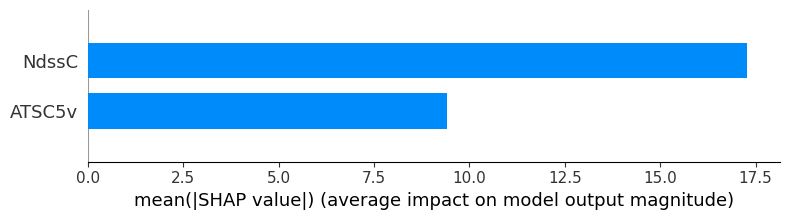

In [17]:
import joblib
import shap
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Load model
# model = joblib.load('model.joblib')

# Load test data (replace with your data)
X_train, X_test, y_train, y_test = train_test_split(molecular_descriptors_df[list(model.feature_names_in_)], molecular_descriptors_df['ee'], random_state=42, test_size=0.15)
feature_names = X_test.columns.tolist()

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Calculate mean absolute SHAP values
shap_values_mean = pd.DataFrame(np.abs(shap_values), columns=feature_names).mean()
importance_df = shap_values_mean.sort_values(ascending=False).reset_index()
importance_df.columns = ['Feature', 'Importance']
print(importance_df)

# SHAP bar plot (optional)
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar")

# Prepare data for Chart.js chart
chart_labels = importance_df['Feature'].values
chart_data = importance_df['Importance'].values

In [18]:
X_test

,ATSC5v,NdssC
50,-955.156347,1
56,208.135984,2
0,335.805685,1
57,26.062117,2
5,226.255289,1
48,-461.035751,1
16,188.600624,1
12,258.337050,1
25,-170.279238,2
59,-184.211894,2


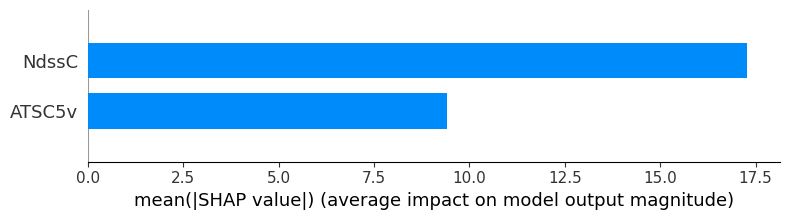

In [19]:
# Bar plot
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar")

  Feature  Importance
0  ATSC5v   14.943916
1   NdssC   12.486256


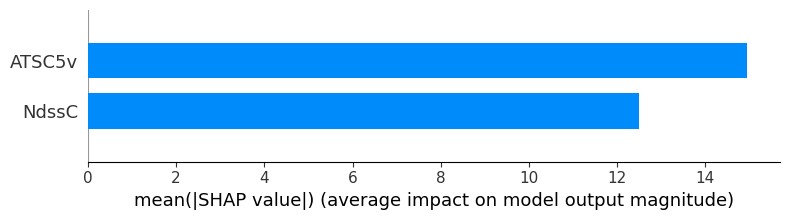

In [20]:
import joblib
import shap
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Load model
# model = joblib.load('model.joblib')

# Load test data (replace with your data)
X_train, X_test, y_train, y_test = train_test_split(molecular_descriptors_df[list(model.feature_names_in_)], molecular_descriptors_df['ee'], random_state=42, test_size=0.15)
feature_names = X_train.columns.tolist()

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# Calculate mean absolute SHAP values
shap_values_mean = pd.DataFrame(np.abs(shap_values), columns=feature_names).mean()
importance_df = shap_values_mean.sort_values(ascending=False).reset_index()
importance_df.columns = ['Feature', 'Importance']
print(importance_df)

# SHAP bar plot (optional)
shap.summary_plot(shap_values, X_train, feature_names=feature_names, plot_type="bar")

# Prepare data for Chart.js chart
chart_labels = importance_df['Feature'].values
chart_data = importance_df['Importance'].values

  Feature  Importance
0  ATSC5v   14.053724
1   NdssC   13.258699


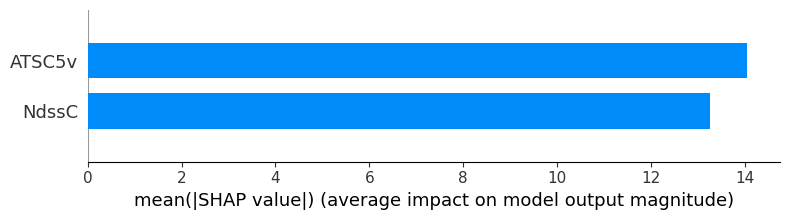

In [21]:
import joblib
import shap
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Load model
# model = joblib.load('model.joblib')

# Load all 
#X_train, X_test, y_train, y_test = train_test_split(molecular_descriptors_df[list(model.feature_names_in_)], molecular_descriptors_df['ee'], random_state=28, test_size=0.2)
X_all = molecular_descriptors_df[list(model.feature_names_in_)]
feature_names = X_all.columns.tolist()

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_all)

# Calculate mean absolute SHAP values
shap_values_mean = pd.DataFrame(np.abs(shap_values), columns=feature_names).mean()
importance_df = shap_values_mean.sort_values(ascending=False).reset_index()
importance_df.columns = ['Feature', 'Importance']
print(importance_df)

# SHAP bar plot (optional)
shap.summary_plot(shap_values, X_all, feature_names=feature_names, plot_type="bar")

# Prepare data for Chart.js chart
chart_labels = importance_df['Feature'].values
chart_data = importance_df['Importance'].values

  Feature  Importance
0   NdssC   13.258699
1  ATSC5v   14.053724


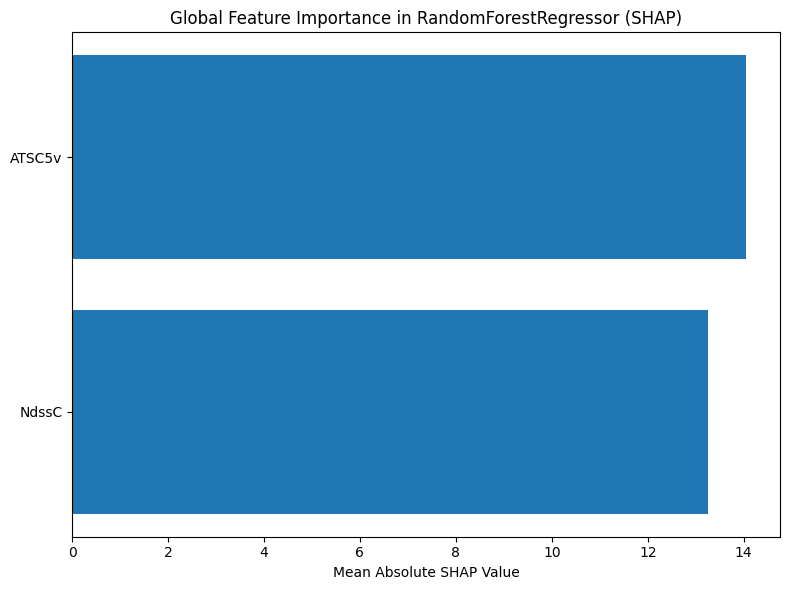

In [22]:
# Calculate mean absolute SHAP values
shap_values_mean = pd.DataFrame(np.abs(shap_values), columns=feature_names).mean()
importance_df = shap_values_mean.sort_values(ascending=True).reset_index()
importance_df.columns = ['Feature', 'Importance']
print(importance_df)

# Create horizontal bar plot
plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Mean Absolute SHAP Value')
plt.title('Global Feature Importance in RandomForestRegressor (SHAP)')
plt.tight_layout()
# Save as PDF
plt.savefig('Figures/feature_importance_plot_new.svg', bbox_inches='tight', format='svg')
#plt.close()
plt.show()

In [23]:
import matplotlib.pyplot as plt

# Get feature importances
importances = model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Chart.js data
chart_labels = importance_df['Feature'].values.tolist()
chart_data = importance_df['Importance'].values.tolist()

In [24]:
chart_labels

['ATSC5v', 'NdssC']

In [25]:
chart_data

[0.7938875498747027, 0.20611245012529728]

In [26]:
# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_all)

# Plot violin plot (standard)
#shap.plots.violin(shap_values, feature_names=list(X_all.columns), max_display=10)

#plt.show()

# Feature names for readability
feature_names = list(X_all.columns)

# Plot layered violin with color based on feature value
shap.plots.violin(shap_values, features=X_all, feature_names=feature_names, plot_type="layered_violin", max_display=10, color_bar=True, plot_size=(10, 15), show=False)

# Explicitly grab the current figure
fig = plt.gcf()

# Save figure to file (adjust path and format as needed)
#fig.savefig('Figures/feature_importance_violin_plot.svg', bbox_inches='tight', format='svg')

# Close the figure to avoid memory issues
plt.close(fig)

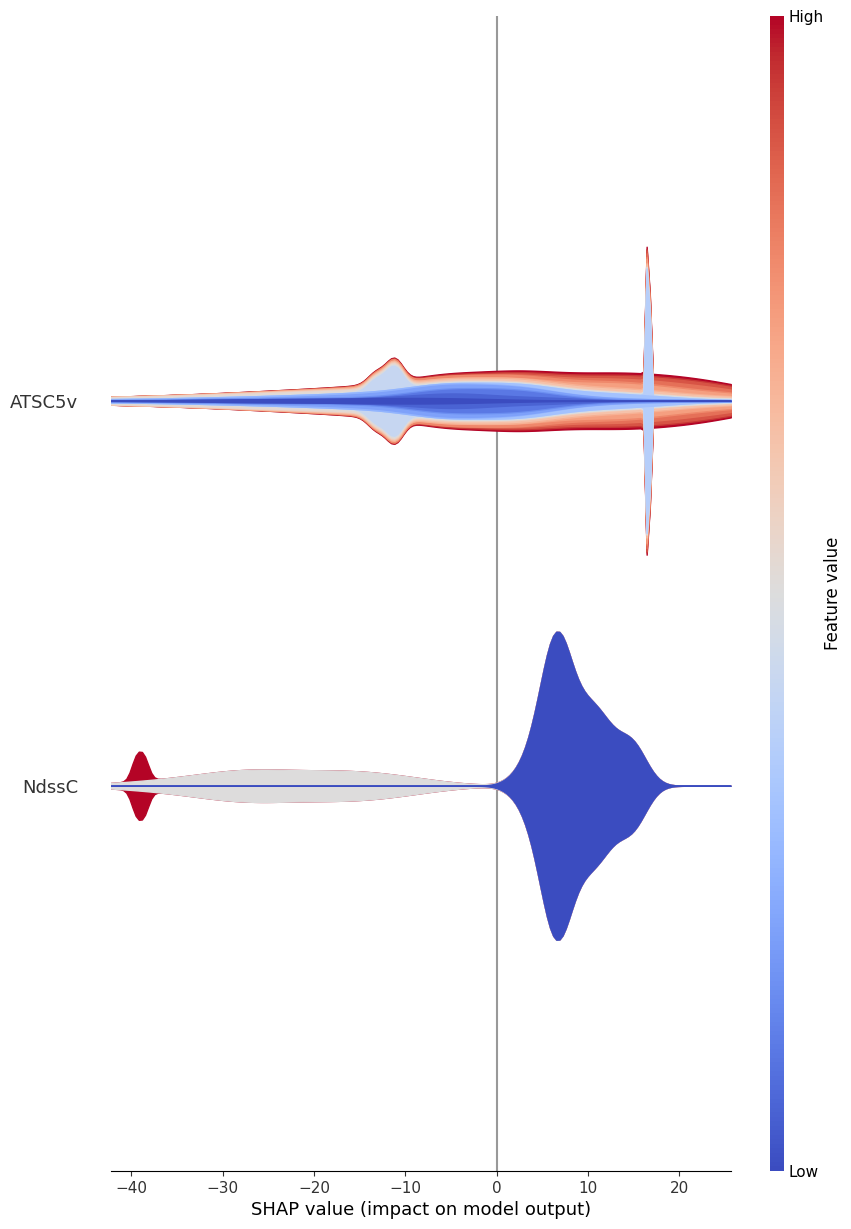

<Figure size 640x480 with 0 Axes>

In [27]:
# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_all)

# Plot violin plot (standard)
#shap.plots.violin(shap_values, feature_names=list(X_all.columns), max_display=10)

#plt.show()

# Feature names for readability
feature_names = list(X_all.columns)

# Plot layered violin with color based on feature value
shap.plots.violin(shap_values, features=X_all, feature_names=feature_names, plot_type="layered_violin", max_display=10, color_bar=True, plot_size=(10, 15), show=True)

# Explicitly grab the current figure
fig = plt.gcf()

# Save figure to file (adjust path and format as needed)
#fig.savefig('Figures/feature_importance_violin_plot.svg', bbox_inches='tight', format='svg')

# Close the figure to avoid memory issues
#plt.close(fig)
plt.show()

In [28]:
import shap
import matplotlib.pyplot as plt

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_all)

# Feature names for readability
feature_names = list(X_all.columns)

# Plot layered violin plot with color bar, max 10 features, without showing immediately
shap.plots.violin(shap_values, features=X_all, feature_names=feature_names,
                  plot_type="layered_violin", max_display=10,
                  color_bar=True, show=False)

# Get the current figure and axis
fig = plt.gcf()
ax = plt.gca()

# Adjust figure size (more compact)
fig.set_size_inches(8, 10)  # Width, Height in inches

# Customize font sizes for better visibility
ax.title.set_fontsize(26)
ax.xaxis.label.set_fontsize(22)
ax.yaxis.label.set_fontsize(22)
ax.tick_params(axis='both', which='major', labelsize=14)

# Optionally customize legend font size if present
legend = ax.get_legend()
if legend:
    for text in legend.get_texts():
        text.set_fontsize(20)

# Use tight layout for compactness
plt.tight_layout()

# Save to file with tight bounding box for paper use
fig.savefig('Figures/feature_importance_violin_plot.svg', bbox_inches='tight', format='svg')

# Close figure to free memory
plt.close(fig)

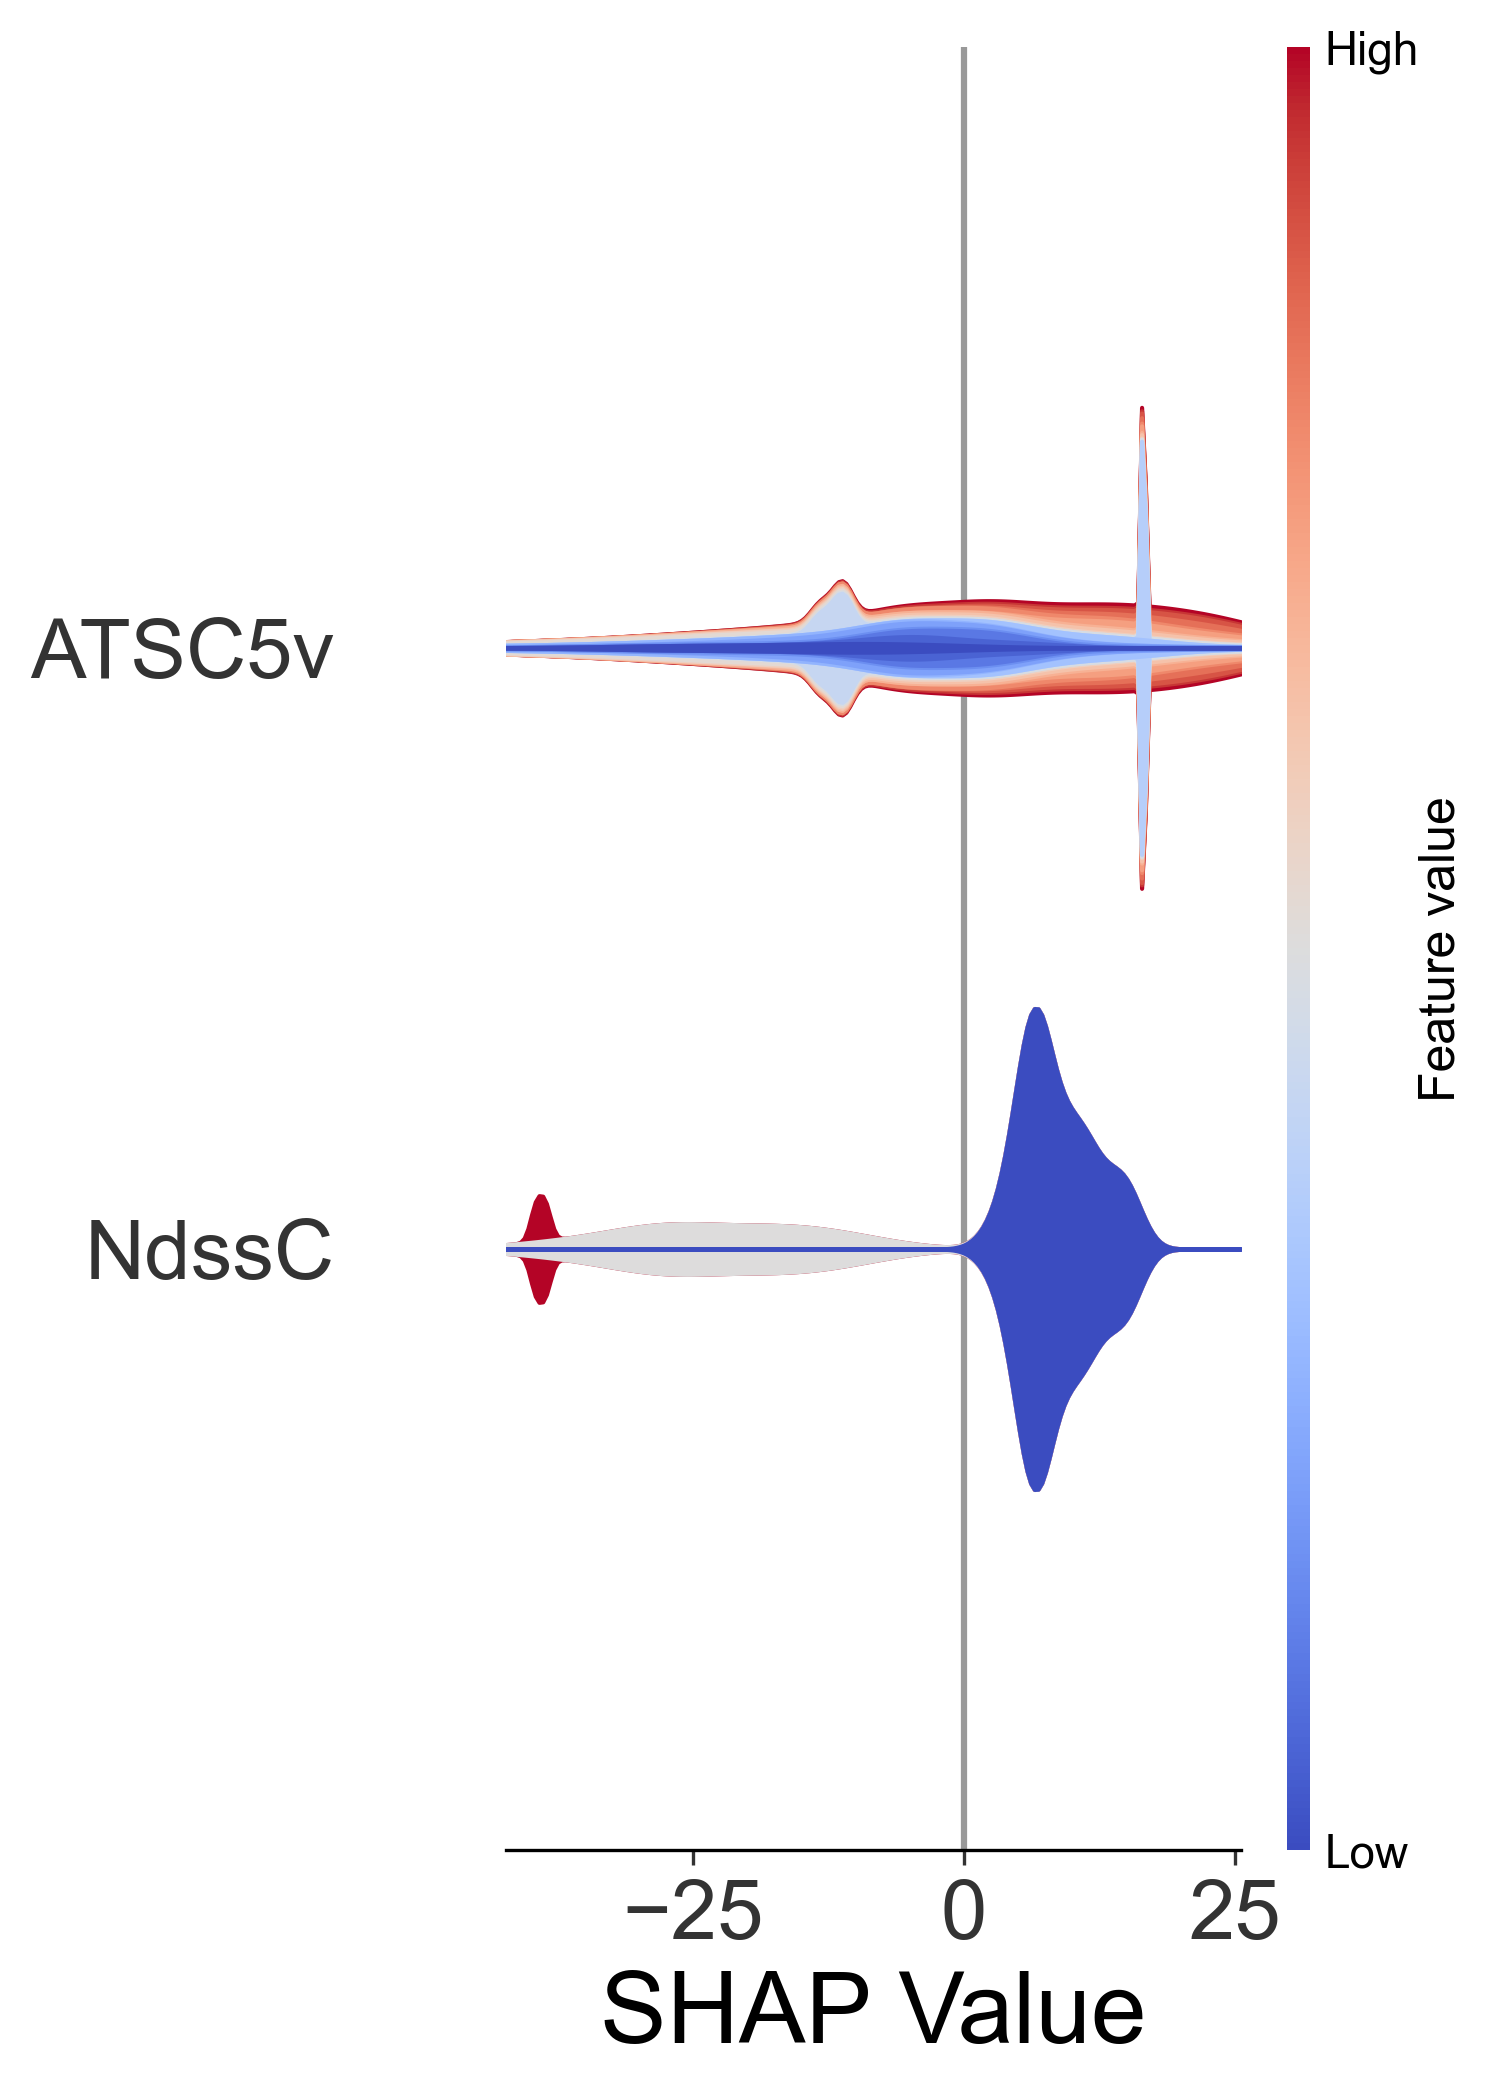

In [29]:
import shap
import matplotlib.pyplot as plt

# Set default font properties before plotting
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 18,
    'figure.dpi': 300,
})

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_all)

# Feature names for readability
feature_names = list(X_all.columns)

# Plot layered violin plot with color bar, max 8 features, show=False
shap.plots.violin(shap_values, features=X_all, feature_names=feature_names,
                  plot_type="layered_violin",
                  max_display=8,
                  color_bar=True, show=False)

# Get current figure and axis
fig = plt.gcf()
ax = plt.gca()

# Adjust figure size for compact but readable display
fig.set_size_inches(6, 8)

# Customize axis labels and ticks for better visibility
ax.set_xlabel('SHAP Value', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=20)

# Customize colorbar font size
cbar = ax.collections[0].colorbar
if cbar:
    cbar.set_label('Feature Value', fontsize=20)
    cbar.ax.tick_params(labelsize=18)

# Remove legend if present
legend = ax.get_legend()
if legend:
    legend.remove()

# Adjust y-tick labels for better alignment and font size
for label in ax.get_yticklabels():
    label.set_fontsize(20)
    label.set_ha('right')
    label.set_position((label.get_position()[0] - 0.1, label.get_position()[1]))

# Use tight layout with extra padding to prevent clipping
plt.tight_layout(pad=2)

# Save figure with high DPI and tight bounding box for small, sharp image
fig.savefig('Figures/feature_importance_violin_plot.svg', bbox_inches='tight', format='svg', dpi=300)

plt.show()
plt.close(fig)
